# 1 Dataset Overview and Making Pivot Table

In [1]:
import pandas as pd

In [2]:
# reading csv 
df_population_raw = pd.read_csv("population_total.csv")

In [3]:
# show dataset
df_population_raw

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09
...,...,...,...
4180,United States,1965.0,1.997337e+08
4181,United States,1960.0,1.867206e+08
4182,United States,1955.0,1.716853e+08
4183,India,1960.0,4.505477e+08


## 1.1 Making a Pivot Table 

.pivot(): Returns reshaped DataFrame organized 
by given index/column values ("Pivot without aggregation")

In [4]:
# dropping null values, inplace+True saves changes to dataframe
df_population_raw.dropna(inplace=True)

In [5]:
# making a pivot table
df_pivot = df_population_raw.pivot(index="year",
                        columns="country",
                        values="population")

In [6]:
# Selecting some countries
df_pivot = df_pivot[['United States','India','China','Indonesia','Brazil']]

In [7]:
# show pivot table
df_pivot

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,4.098806e+08,6.122416e+08,77273425.0,62533919.0
1960.0,186720571.0,4.505477e+08,6.604081e+08,87751068.0,72179226.0
1965.0,199733676.0,4.991233e+08,7.242190e+08,100267062.0,83373530.0
1970.0,209513341.0,5.551898e+08,8.276014e+08,114793178.0,95113265.0
1975.0,219081251.0,6.231029e+08,9.262409e+08,130680727.0,107216205.0
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1985.0,240499825.0,7.843600e+08,1.075589e+09,164982451.0,135274080.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
1995.0,265163745.0,9.639226e+08,1.240921e+09,196934260.0,162019896.0


# 2 Data Visualization with Pandas

# 2.1 Lineplot

<Axes: title={'center': 'Population (1955-2020)'}, xlabel='Year', ylabel='Population'>

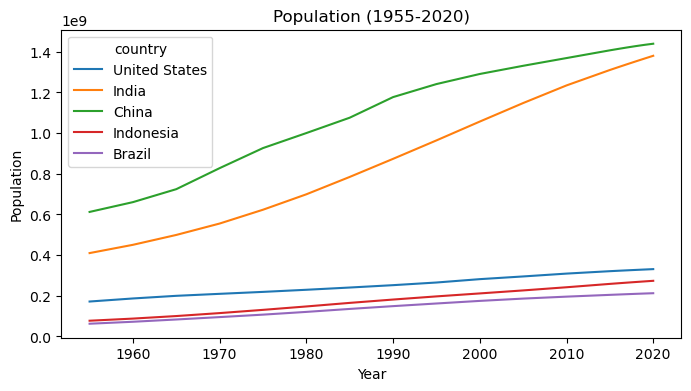

In [14]:
df_pivot.plot(kind='line', xlabel="Year", ylabel="Population", 
              title ="Population (1955-2020)", figsize=(8,4))

# 3 Barplot

## 3.1 Single Barplot

In [23]:
# selecting only one year (2020)
df_pivot_2020 = df_pivot[df_pivot.index.isin([2020])]

In [24]:
# showing new dataframe
df_pivot_2020

country,United States,India,China,Indonesia,Brazil
year,,,,,
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


Note: when making braplots, text data in the index, so name of countries will be used in index

In [26]:
# transpose dataframe from rows to columns or vice versa
df_pivot_2020 = df_pivot_2020.T

In [28]:
df_pivot_2020

year,2020.0
country,
United States,3.310027e+08
India,1.380004e+09
China,1.439324e+09
Indonesia,2.735236e+08
Brazil,2.125594e+08


<Axes: title={'center': 'Population 2020'}, xlabel='Country', ylabel='Population'>

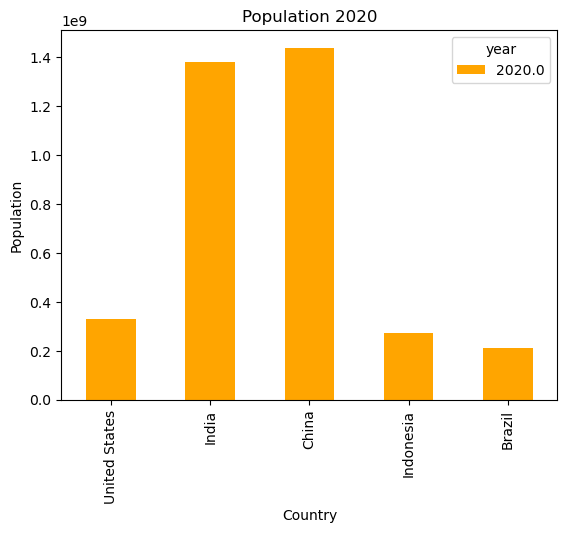

In [34]:
# making barplot
df_pivot_2020.plot(kind='bar', color='orange', 
                   xlabel="Country", ylabel="Population",
                   title="Population 2020")

## 3.2 Barplot grouped by 'n' variables

In [38]:
# selecting a few years
df_pivot_sample = df_pivot[df_pivot.index.isin([1980, 19090, 2000, 2010, 2020])]
df_pivot_sample 

country,United States,India,China,Indonesia,Brazil
year,,,,,
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
2000.0,281710909.0,1.056576e+09,1.290551e+09,211513823.0,174790340.0
2010.0,309011475.0,1.234281e+09,1.368811e+09,241834215.0,195713635.0
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


<Axes: xlabel='Year', ylabel='Population'>

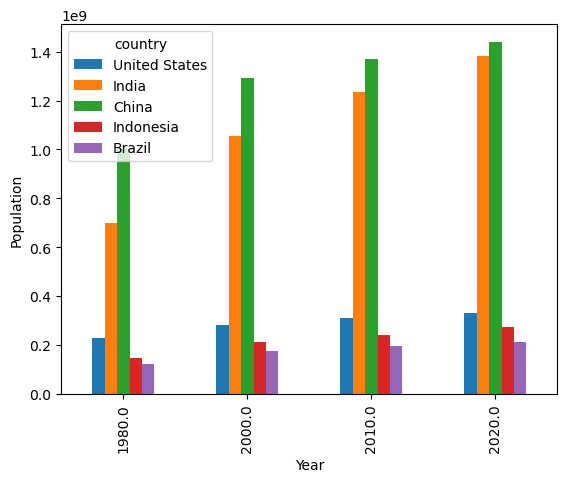

In [41]:
# making grouped barplot
df_pivot_sample.plot(kind='bar', xlabel="Year", ylabel="Population")

# 4 Piechart

In [45]:
# changing column name
df_pivot_2020.rename(columns={2020:"2020"}, inplace=True)

<Axes: title={'center': 'Population in 2020 (%)'}, ylabel='2020'>

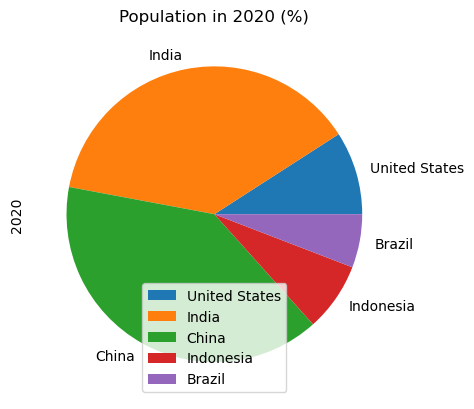

In [49]:
# making the plot
df_pivot_2020.plot(kind='pie', y='2020', title='Population in 2020 (%)')

# 5 Boxplot

## 5.1 Single Boxplot

<Axes: ylabel='Population'>

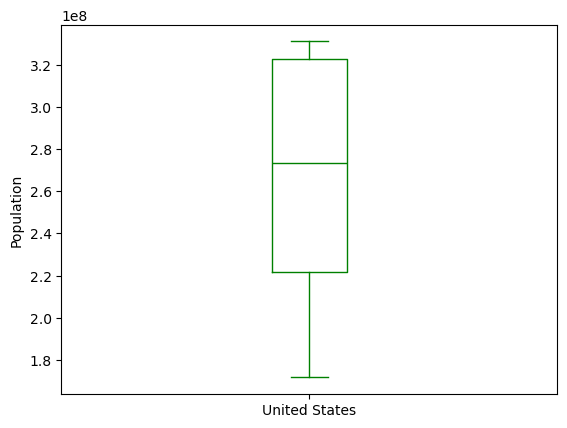

In [52]:
df_pivot['United States'].plot(kind='box', color='green',
                              ylabel='Population')

## 5.2 Multiple Boxplot

<Axes: ylabel='Population'>

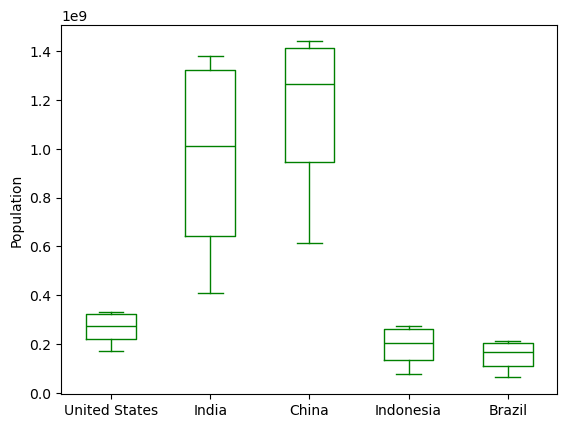

In [54]:
df_pivot.plot(kind='box', color='green',
             ylabel='Population')

# 6 Histogram

Note: Histogram is a graph that organizes a group of data points into ranges

<Axes: ylabel='Frequency'>

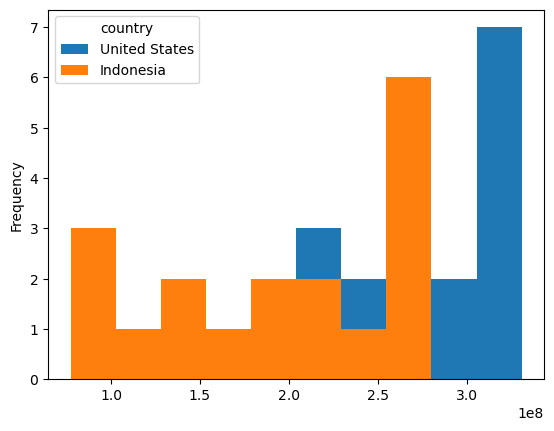

In [57]:
df_pivot[['United States', 'Indonesia']].plot(kind='hist')

# 7 ScatterPlot

In [64]:
# selecting a sample of the raw data
df_sample = df_population_raw[df_population_raw['country'].isin(['United States', 'India', 'China', 'Indonesia', 'Brazil'])]

<Axes: xlabel='year', ylabel='population'>

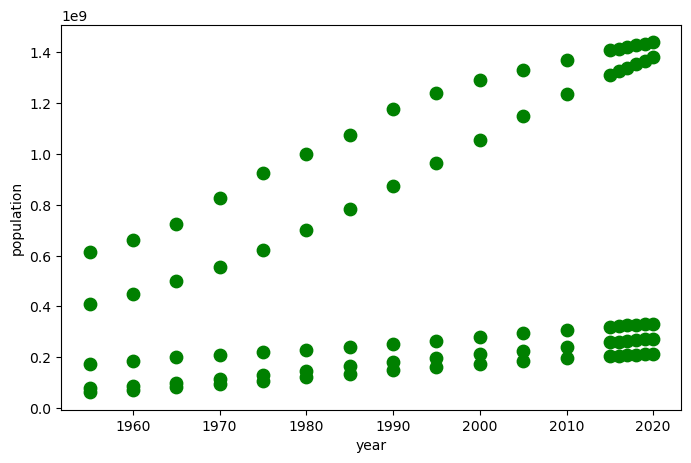

In [65]:
# creating the plot
df_sample.plot(kind='scatter',
               x='year',
               y='population',
               figsize=(8,5),
               color='green',
               s=80)